In [6]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

#dataset_location = "/tmp/clevr-act-6-var-cam2"
dataset_location = "/data/lmbraid19/argusm/datasets/clevr-real-block-simple-v4"
#dataset_location = "/data/lmbraid19/argusm/datasets/clevr-real-block-v3"
#dataset_location = "/data/lmbraid19/argusm/datasets/clevr-real-1of5c-v1"
dataset_location = Path(dataset_location)

model_location = Path("/data/lmbraid19/argusm/models/")
#model_path = model_location / "clevr-act-7-depth_l40" / "checkpoint-4687"
#model_path = model_location / "clevr-act-6-var-cam2_hf_af_lr3e5" / "checkpoint-4687"
#model_path = model_location / "clevr-act-7-depth_rbg20" / "checkpoint-4687"
# model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"
#model_path = model_location / "clevr-act-7-depth_rbg60" / "checkpoint-4687"


model_path = Path("/data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depthstage1-bs32-bs_dev2_n_repeat2/checkpoint-6875")
#model_path = model_location / "clevr-act-7-depth_depth_l40" / "checkpoint-4687"
if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
dataset_location /data/lmbraid19/argusm/datasets/clevr-real-block-simple-v4
moadel_path is /data/lmbraid21/bratulic/max_pali/models/clevr-act-7-depthstage1-bs32-bs_dev2_n_repeat2/checkpoint-6875


In [7]:
from data_loader_jsonl import JSONLDataset, ValidDataset

test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

dataset len 160


160


  0%|          | 0/3 [00:00<?, ?it/s]


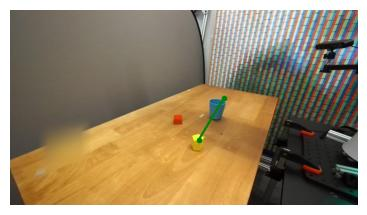
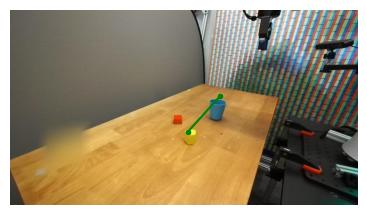
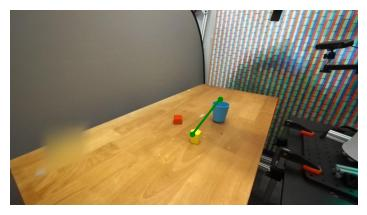

In [8]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = min(3*1, len(test_dataset))
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [4]:

import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")
model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE)
    return inputs

Using device: cuda
loaded processor.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
if return_depth:
    def collate_fn(batch):
        images, labels = zip(*batch)
        prefixes = ["<image><image>" + label["prefix"] for label in labels]
        #suffixes = [label["suffix"] for label in labels]
        images_flat = [img for img_list_x in images for img in img_list_x]
        inputs = processor(
            text=prefixes,
            images=images_flat,
            return_tensors="pt",
            #suffix=suffixes,
            padding="longest"
        ).to(TORCH_DTYPE).to(DEVICE)
        return inputs

  0%|          | 0/20 [00:00<?, ?it/s]


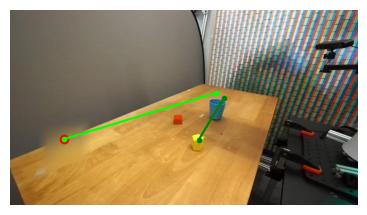
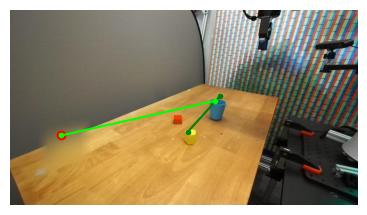
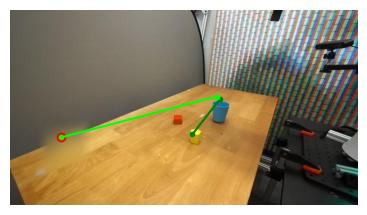
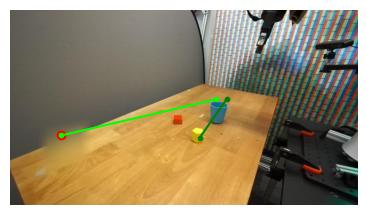
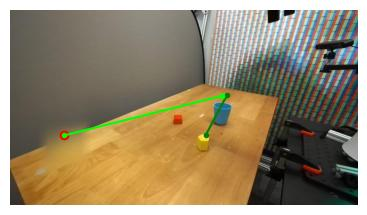
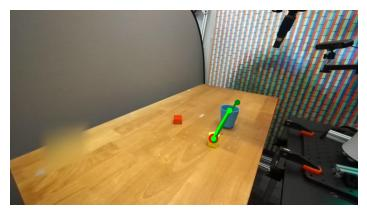
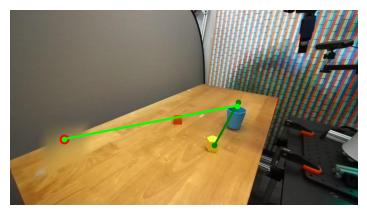
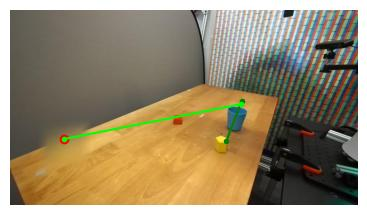
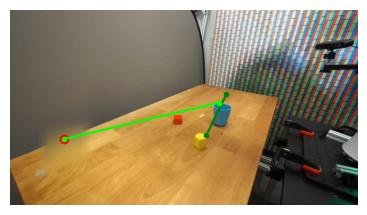
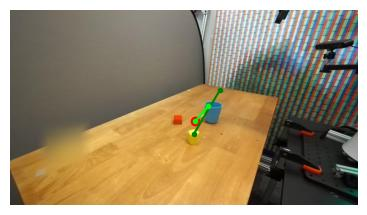
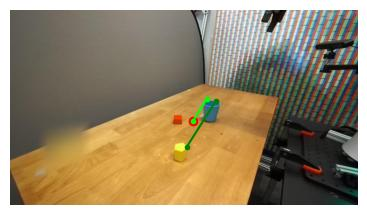
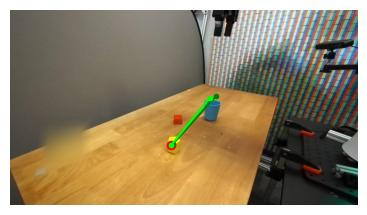
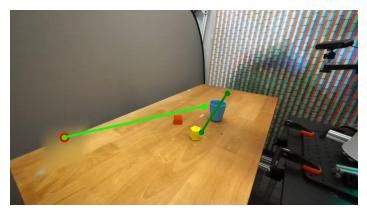
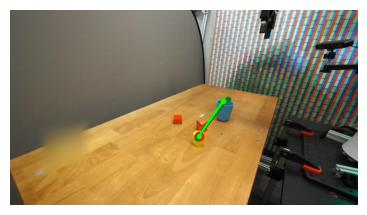
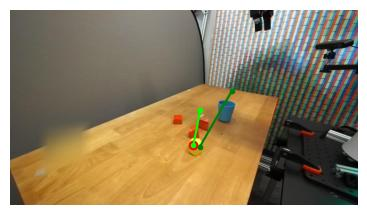
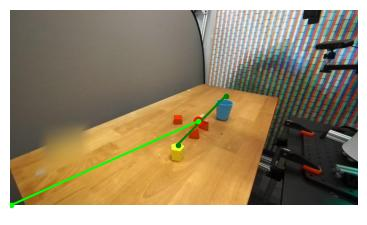
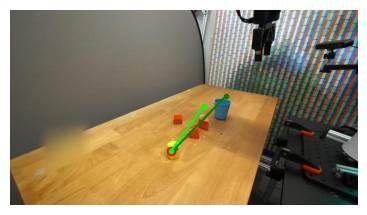
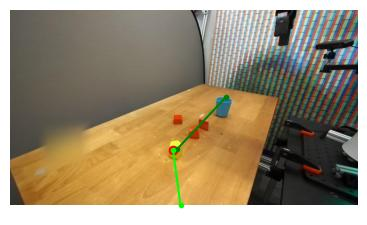
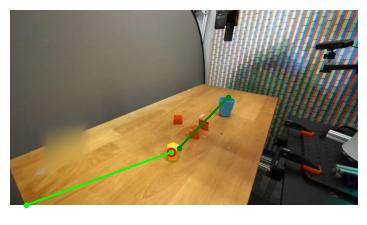
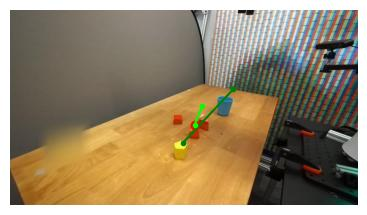
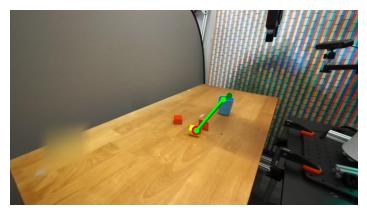
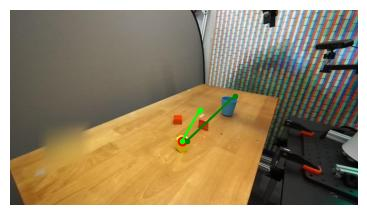
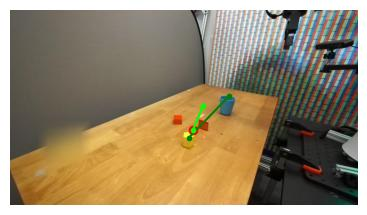
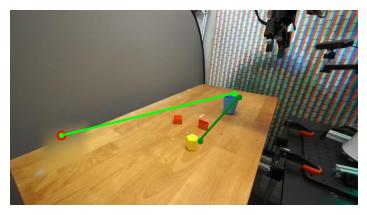
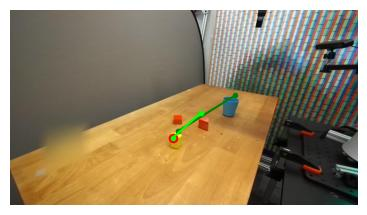
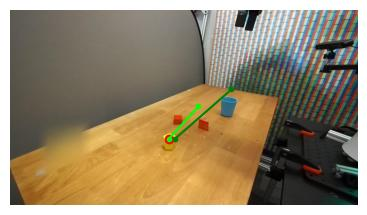
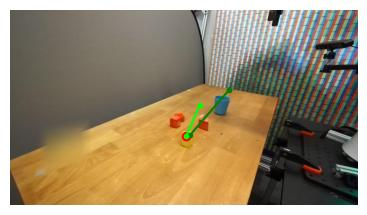
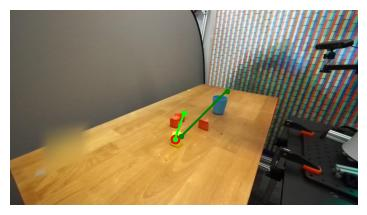
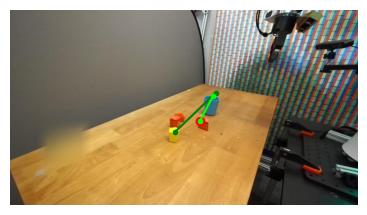
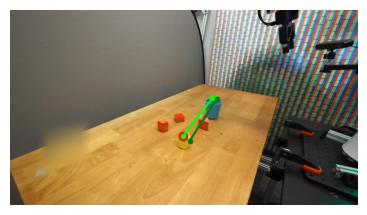
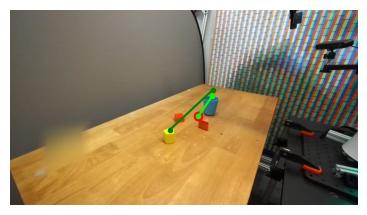
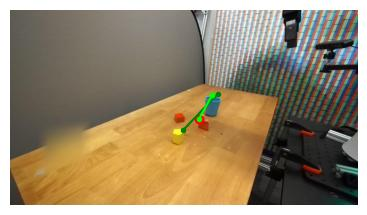
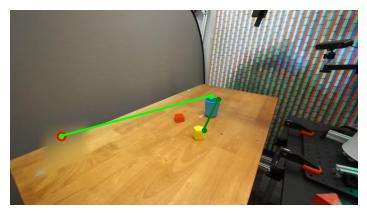
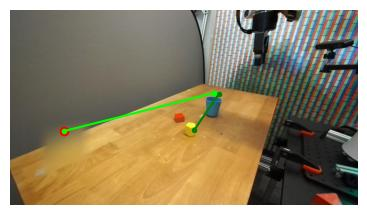
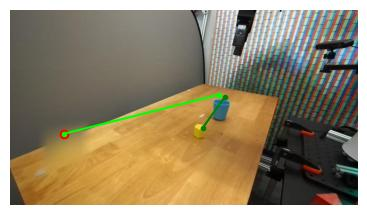
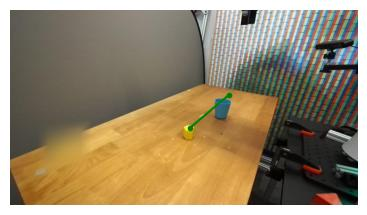
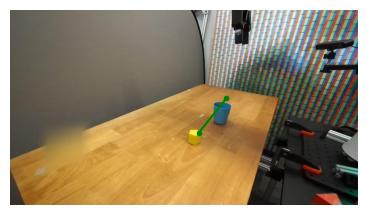
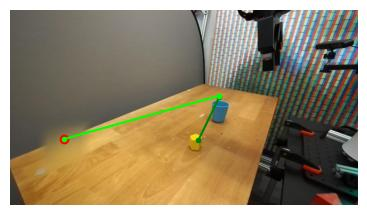
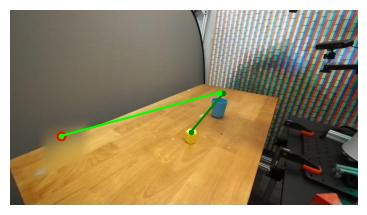
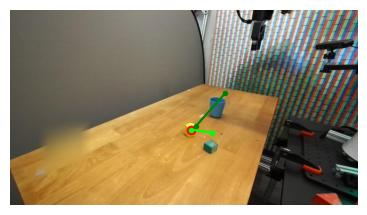
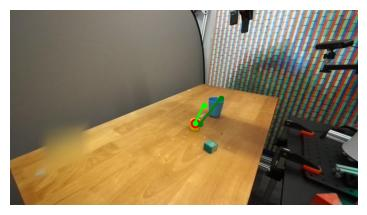
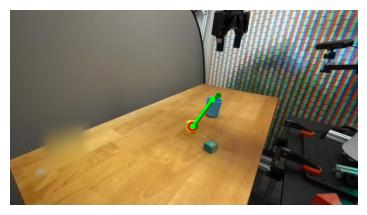
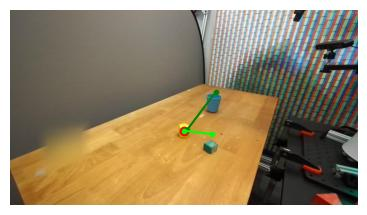
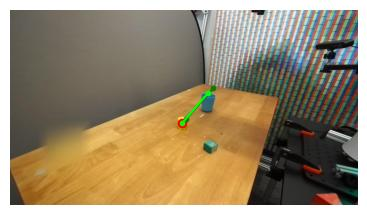
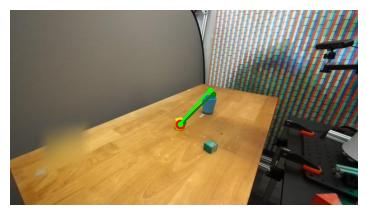
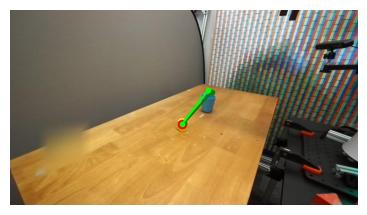
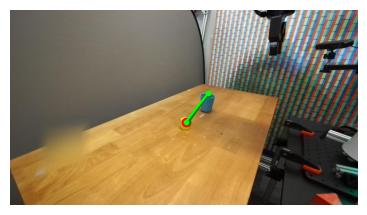
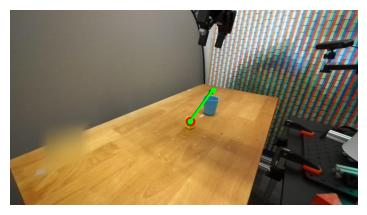
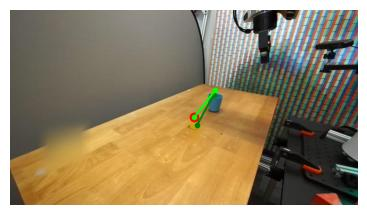
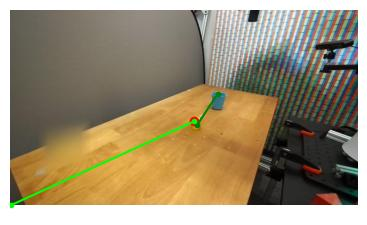
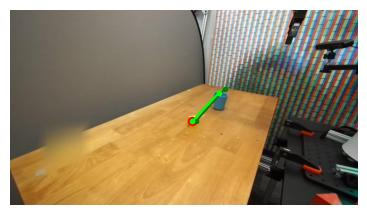
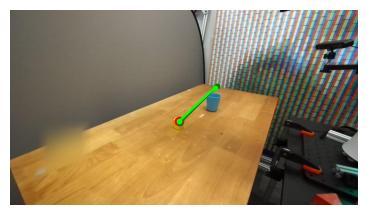
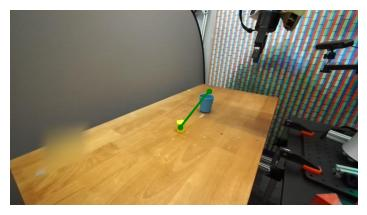
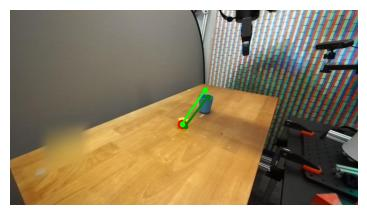
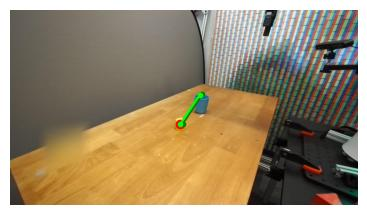
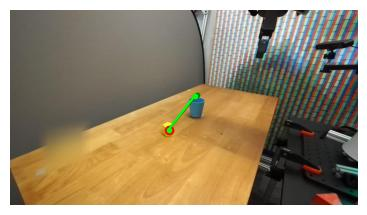
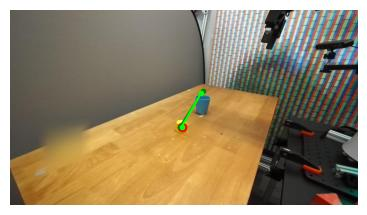
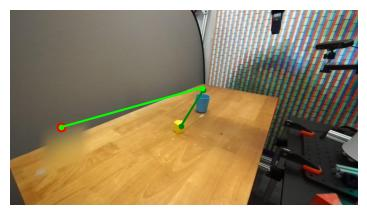
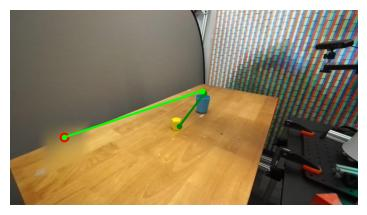
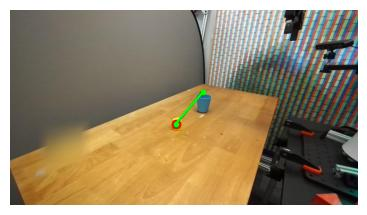
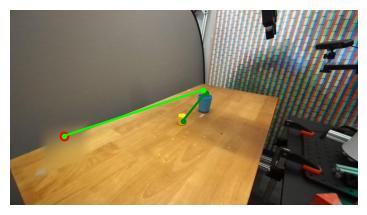
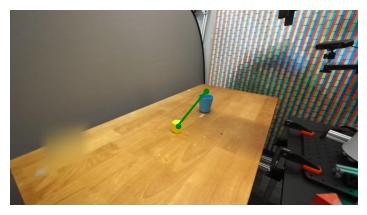
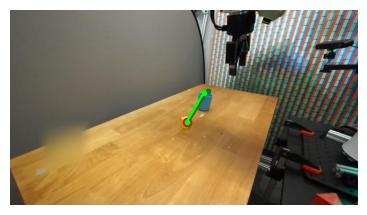
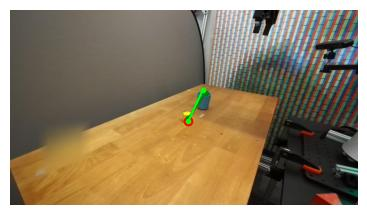
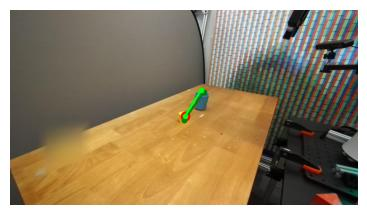
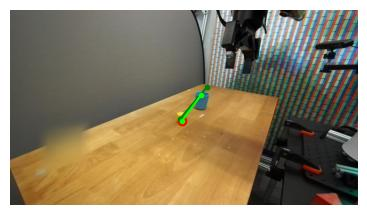
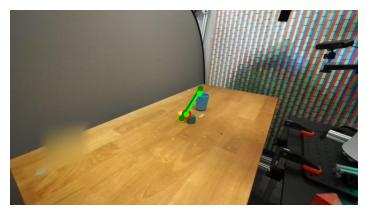
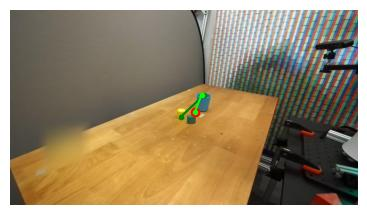
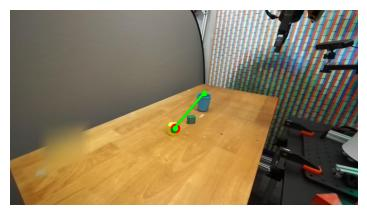
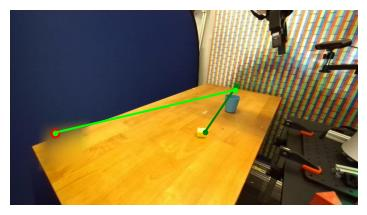
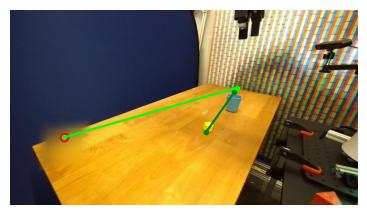
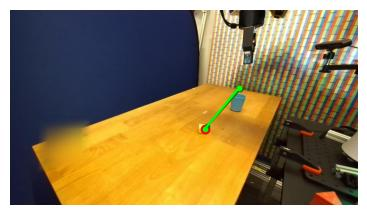
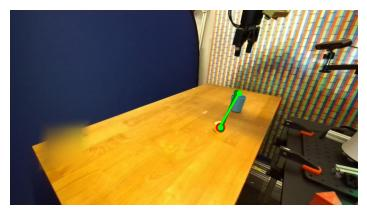
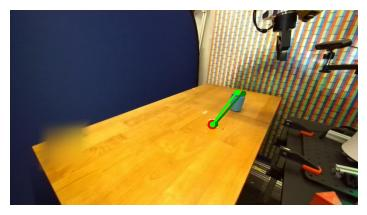
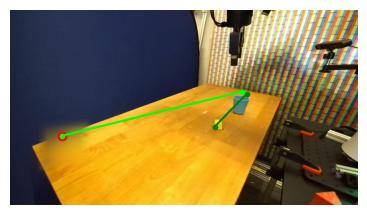
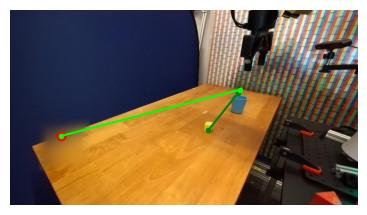
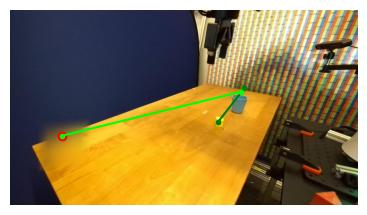
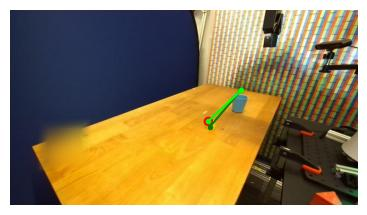
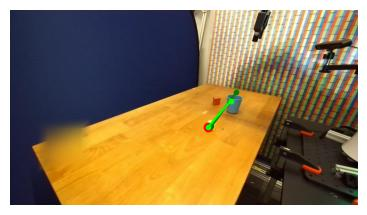
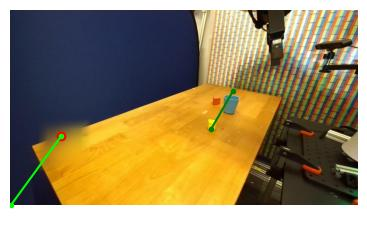
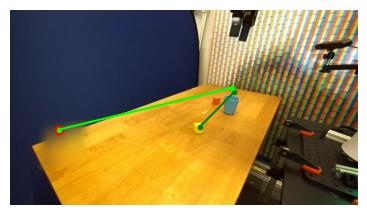
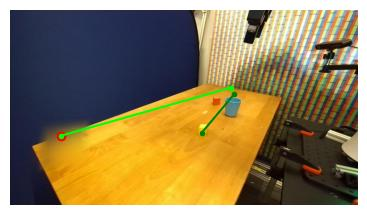
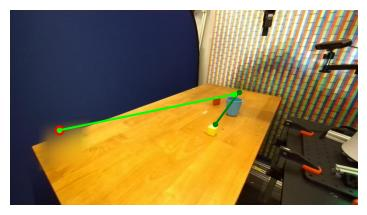
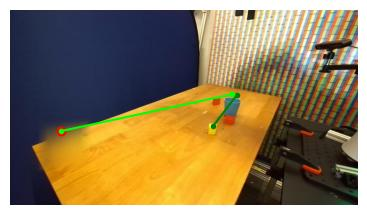
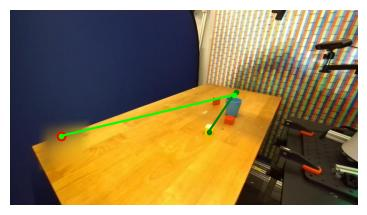
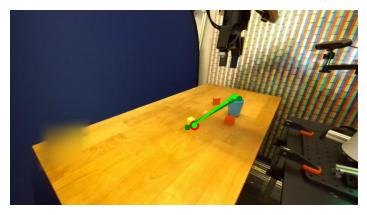
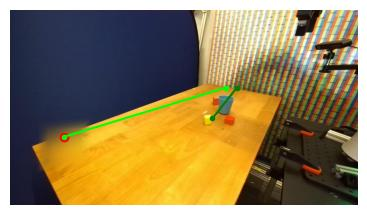
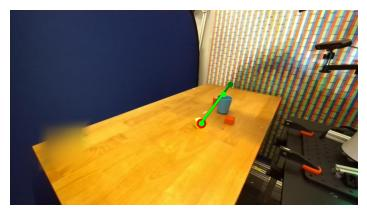
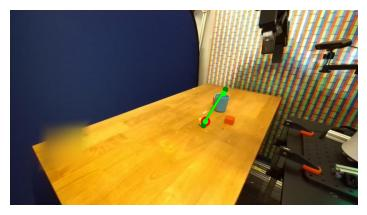
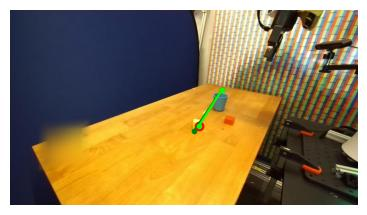
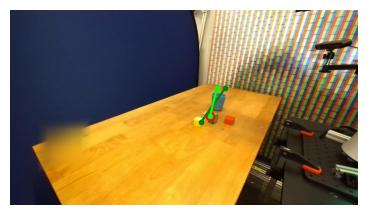
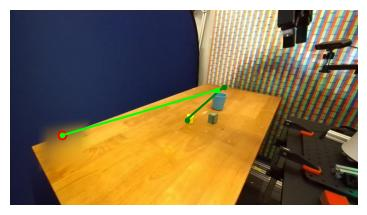
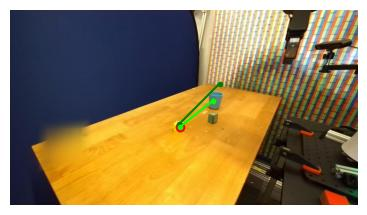
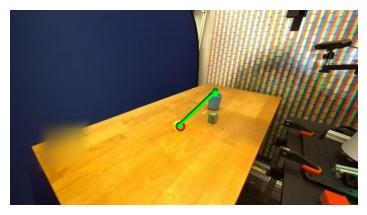
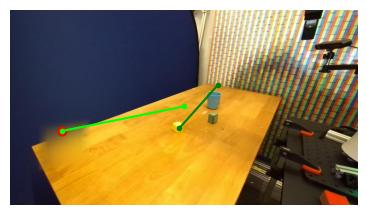
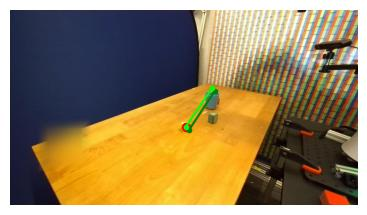
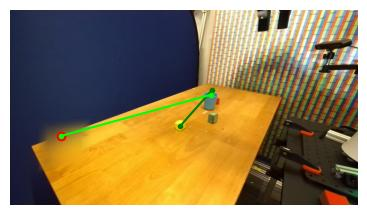
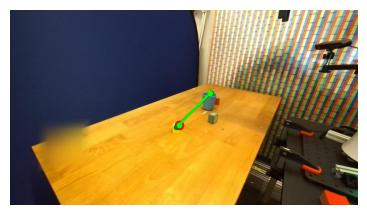
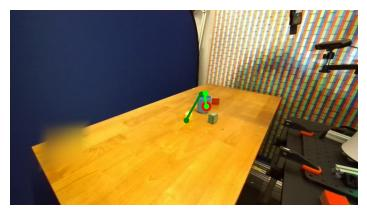
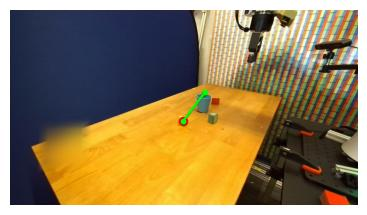
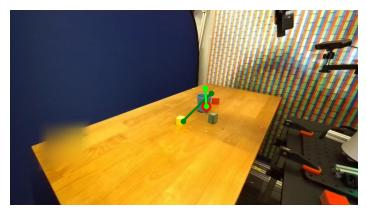
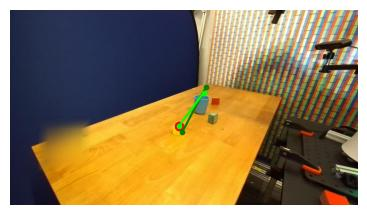
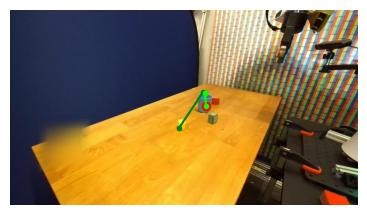
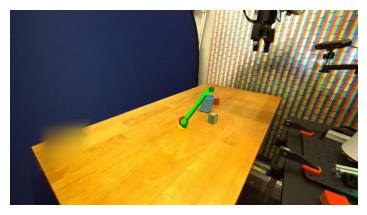
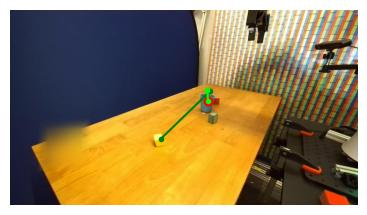
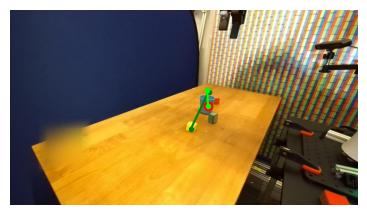
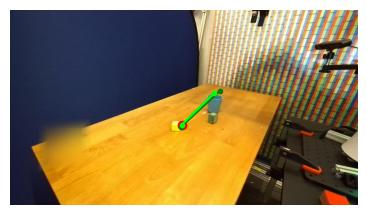
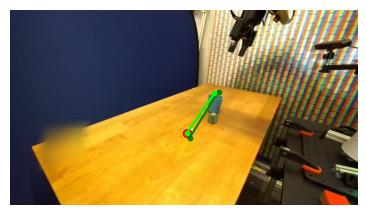
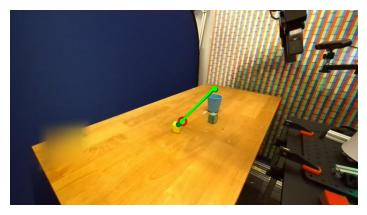
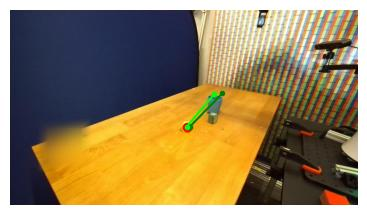
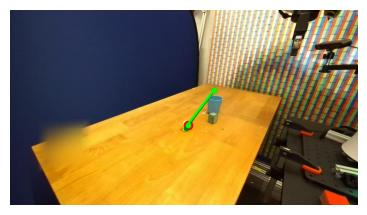
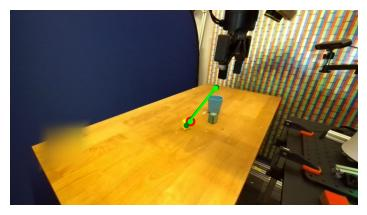
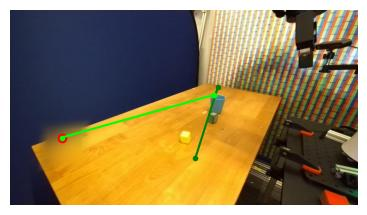
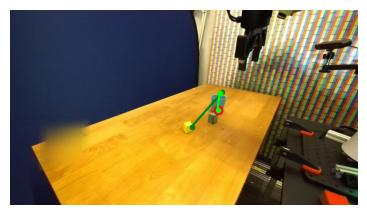
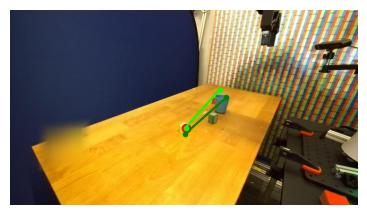
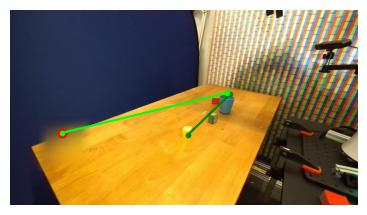
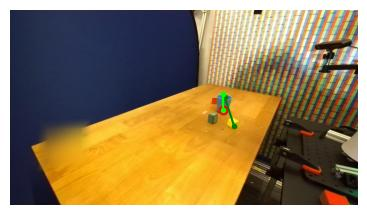
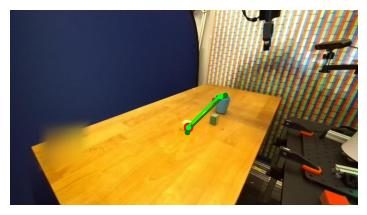
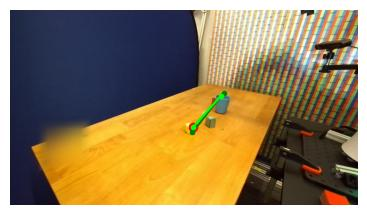
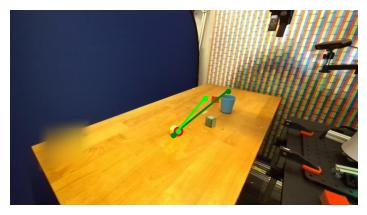
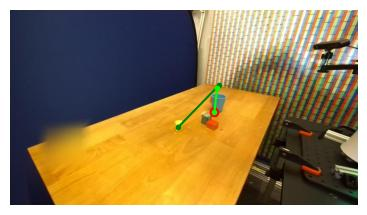
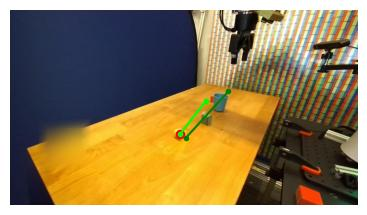
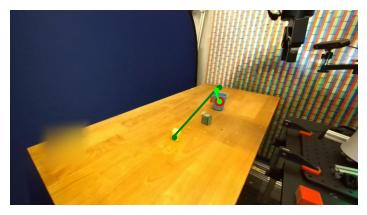
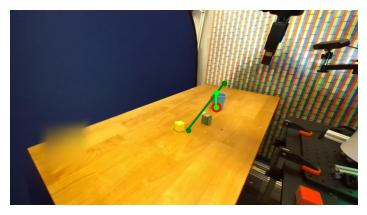
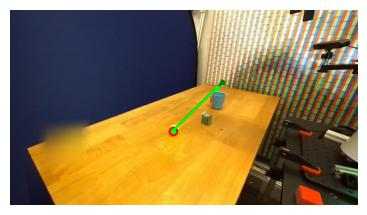
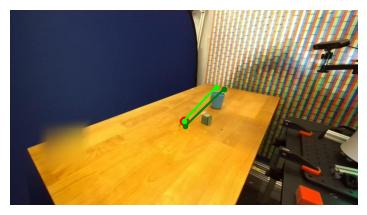
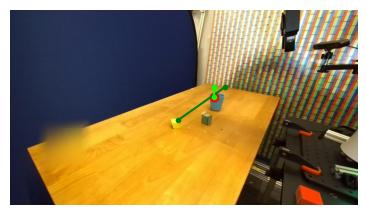
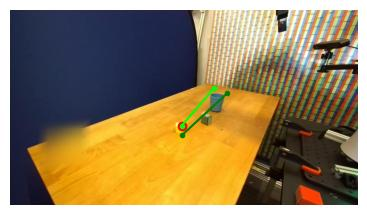
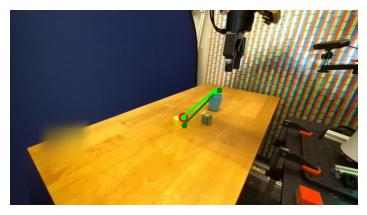
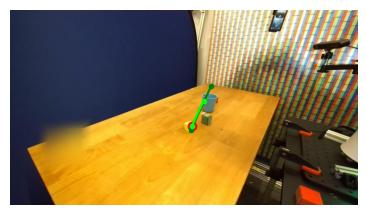
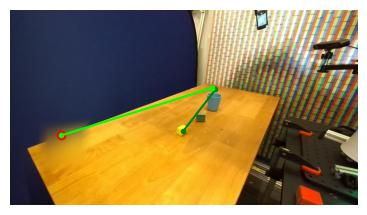
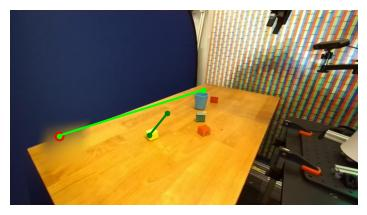
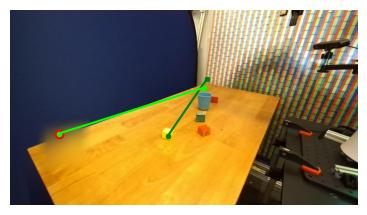
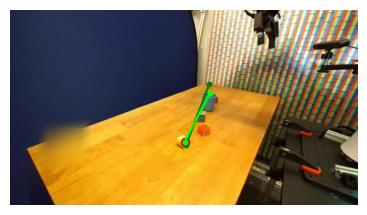
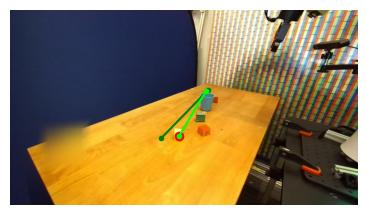
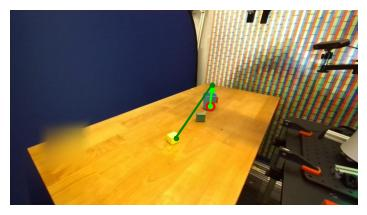
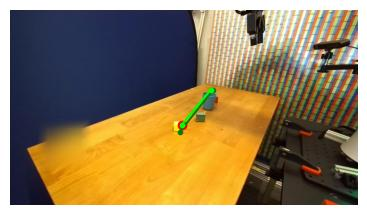
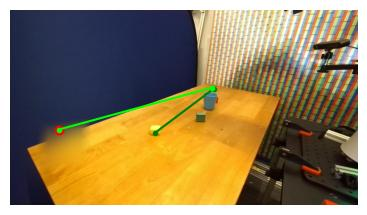
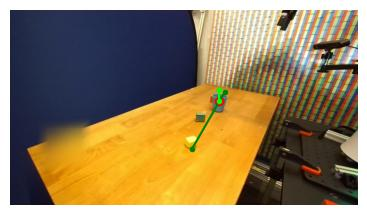
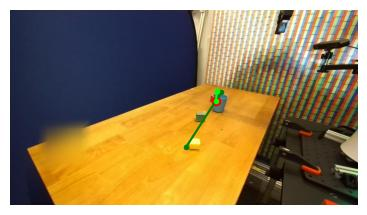
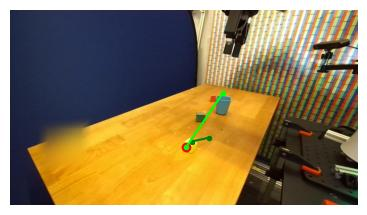
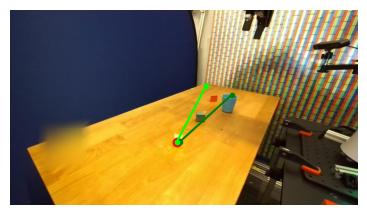
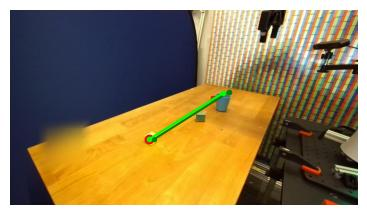
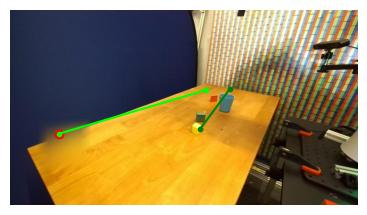
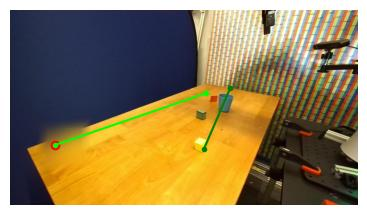
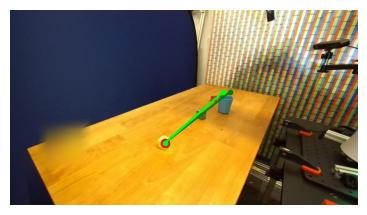
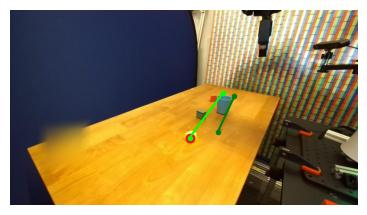
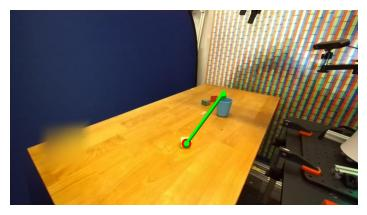
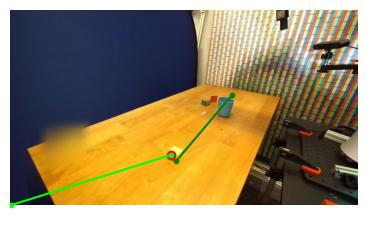
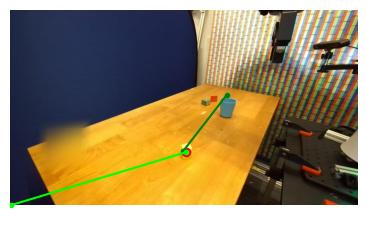
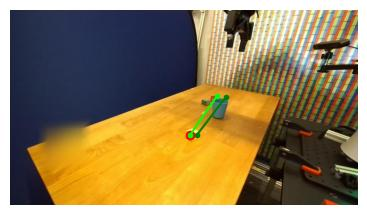
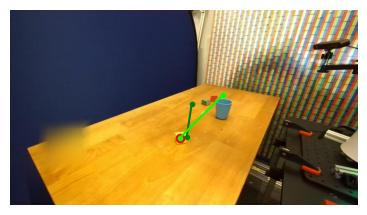
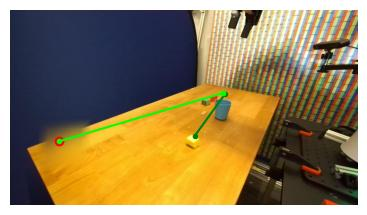
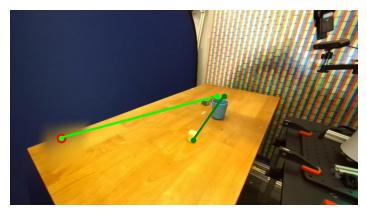
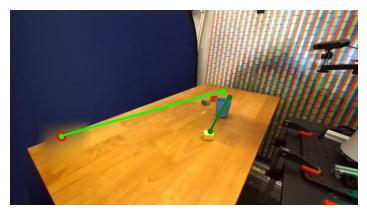
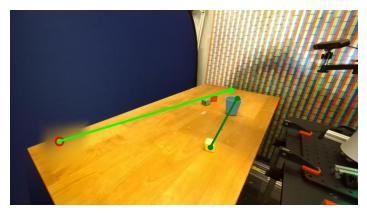
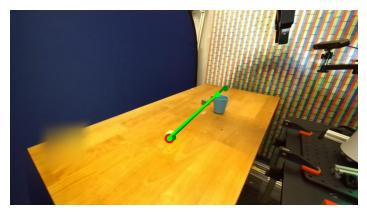
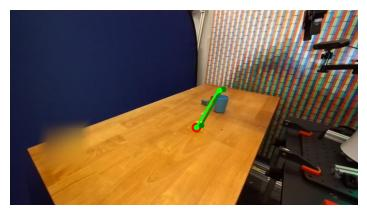
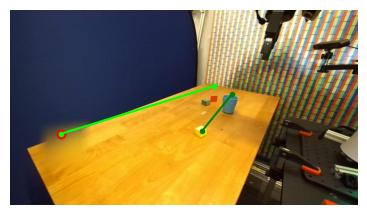
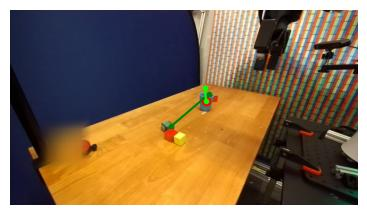

In [9]:
from tqdm.notebook import tqdm
from utils_vis import render_example
from utils_trajectory import DummyCamera
from math import ceil

eval_batch_size = 8
#if return_depth:
#    eval_batch_size = 1

#def augment_sample(sample):
#    sample[1]["prefix"] = sample[1]["prefix"].replace("blue cup", "crockery").replace("cup","crockery")
    
#test_samples = eval_batch_size*3
test_samples = len(test_dataset)
pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=ceil(test_samples / eval_batch_size)):
    batch = [test_dataset[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch)
    inputs = inputs.to(DEVICE)
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation[:, prefix_length:]]
    pred_list.extend(decoded)
    
    for batch_entry, decoded_str in zip(batch, decoded):
        if return_depth:
            (depth, image), sample = batch_entry
        else:
            image, sample = batch_entry
        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

In [86]:
import re
import numpy as np
import matplotlib.pyplot as plt

results = []
for i, pred in enumerate(pred_list):
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", suffix)]
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", pred)]
    if len(decode_p) != 12:
        continue
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

results[:, 0:2] = results[:, 0:2]/1024*224 
results[:, 6:8] = results[:, 6:8]/1024*224 


keypoint = ["object","container"]
action_labels = ["x","y","depth","r1","r2","r3"]*2
units         = ["px","px","cm","rad","rad","rad"]*2
plot_hist=True
if plot_hist:
    fig, axes = plt.subplots(2, 3, figsize=(12, 12*2/3))  # 3 rows x 4 columns of histograms
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    for i in range(2):
        for j in range(6):
            axes[j].hist(results[:, i*6+j], bins=20, alpha=0.7,  edgecolor='black', label=keypoint[i])
            axes[j].set_title(f'Hist. {action_labels[j]} err.')
            axes[j].set_xlabel(f"{action_labels[j]} err. [{units[j]}]")
            axes[j].set_ylabel('Frequency')
            axes[j].legend()
            
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()
print("L1_depth", np.mean(np.abs(results[:,2])))

In [80]:
np.mean(np.abs(results), axis=0)
# RGB Networks
# Valid Samples: 157 L1: 35.67 (no-agug)
# Valid Samples: 160 L1: 34.35 (prompt cleaning) 33.89
# Valid Samples: 160 L1: 34.62 (prompt cleaning + simplify text)  -- similar

# Valid Samples: 160 L1: 24.96 (rgb20 = augmentation + random background (CVPR09-dataset))
# Valid Samples: 160 L1: 26.61 (rgb20 + simplify text) -- worse
# Valid Samples: 150 L1: 40.55 (augmentation + DROID background)  -- way worse


# With depth (only 31 samples for real data)
# Valid Samples: 31 L1: 29.24 (no text aug, NaN-to-Max eval)
# Valid Samples: 31 L1: 28.58  L1_depth 6.29375 (no text aug, Nan-to-Min eval)  
# Valid Samples: 160 L1: 27.93 6.29375 (no text aug, all-zero)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.array([13.68125, 48.0125 ,  8.025  ,  8.475  , 20.1875 , 29.4    ,  # without masking v3
        5.2875 ,  4.00625, 15.20625,  8.475  , 20.1875 , 29.4    ])

np.array([ 5.76875, 14.11875,  7.275  , 36.9875 , 53.45   , 18.25625,  # with masking v2 (wrong orientation)
        8.94375,  7.0375 , 16.825  , 36.9875 , 53.45   , 18.25625])



eval_on_blocks = {"baseline":35.67, "+clean prompt": 33.89, "(simplify text)":34.62,
                  "rbg-20%": 24.96, "(droid bg)": 40.55, "text aug": 25.93}


# Extract labels and values
labels, values = zip(*eval_on_blocks.items())

# Plot
plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue', edgecolor='black')

# Formatting
plt.ylabel("L1 Error Mean")
plt.title("Evaluation over Training Data")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.xlabel("Experiment Runs")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Show plot
plt.show()

# Own Data Experiments

In [9]:
from math import ceil
from data_loader_images import ImageFolderDataset
test_dataset2 = ImageFolderDataset("/data/lmbraid19/argusm/datasets/clevr-own-block-v1")

robot_state = "<loc0137><loc0794><loc0057><seg058><seg034><seg017>"
x = "orange block"
y = "purple block"
action_text = "put the {} inside the {}".format(x, y)
prefix = action_text + " " + robot_state
test_dataset2.labels = [dict(prefix=prefix, suffix="")]*len(test_dataset2)

eval_batch_size = 8
test_samples = len(test_dataset2)
pred_list = []
html_imgs = ""
for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=ceil(test_samples / eval_batch_size)):
    batch = [test_dataset2[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch)
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation[:, prefix_length:]]
    pred_list.extend(decoded)
    
    for batch_entry, decoded_str in zip(batch, decoded):
        if return_depth:
            (depth, image), sample = batch_entry
        else:
            image, sample = batch_entry
        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

In [8]:
# from matplotlib import pyplot as plt
# import re
# import numpy as np
# results = []
# suffix_nums = []
# predi_nums = []
# for i in range(test_samples):
#     suffix = test_dataset[i][1]["suffix"]
#     prefix = test_dataset[i][1]["prefix"]
#     decoded = decode_dataset[i]
#     suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", suffix)]
#     try:
#         decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", decoded)]
#     except ValueError:
#         continue
#     if len(decode_p) != 12:
#         continue
#     pred_diff = np.array(suffix_p) - np.array(decode_p)
#     results.append(pred_diff)
#     suffix_nums.append(suffix_p)
#     predi_nums.append(decode_p)

# results = np.array(results)
# #suffix_nums = np.array(suffix_nums) / 1024 * 448
# #predi_nums = np.array(predi_nums) / 1024 * 448

# print(results)
# print(np.abs(results).mean(axis=0).round())

# plot_histogram = True
# if plot_histogram:
#     fig, axes = plt.subplots(4, 3, figsize=(10, 12))  # 3 rows x 4 columns of histograms
#     axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
#     for i in range(12):
#         axes[i].hist(results[:, i], bins=20, alpha=0.7, color='blue', edgecolor='black')
#         axes[i].set_title(f'Histogram for Column {i + 1}')
#         axes[i].set_xlabel('Value')
#         axes[i].set_ylabel('Frequency')

#     plt.tight_layout()  # Adjust layout for better spacing
#     plt.show()

# Simulation Eval

In [9]:
# import numpy as np
# class ModelWrapper:
#     def __init__(self, transformers_model=model):
#         self.model = transformers_model
    
#     def make_predictions(self, image, prefix):
#         prefix = "<image>" + prefix
#         image = Image.fromarray(image)
#         inputs = processor(text=prefix,
#                            images=image,
#                            return_tensors="pt").to(TORCH_DTYPE).to(DEVICE)
#         prefix_length = inputs["input_ids"].shape[-1]
#         with torch.inference_mode():
#             generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
#             generation = generation[0][prefix_length:]
#             decoded = processor.decode(generation, skip_special_tokens=True)
#         return None, None, None, decoded
# model_wrapped = ModelWrapper(model)

# i = 0
# image, label = test_dataset[i]
# print(image)
# print(label["prefix"])
# res = model_wrapped.make_predictions(np.asarray(image), label["prefix"])
# print(res)


In [10]:
# %reload_ext autoreload
# %autoreload 2
# import json
# from PIL import Image
# from mani_skill.examples.run_env import Args, iterate_env, save_dataset

        
# parsed_args = Args()
# parsed_args.env_id = "ClevrMove-v1"
# parsed_args.render_mode = "rgb_array"
# parsed_args.control_mode = "pd_joint_pos"

# env_iter = iterate_env(parsed_args, vis=False, model=model_wrapped)

In [11]:
# for i in range(25):
#     next(env_iter)

In [12]:
# import torch
# model_path = model_location / "clevr-act-6-var-cam2_hf_af_lr3e5"
# training_args_good = torch.load(model_path / "checkpoint-4687" / "training_args.bin", weights_only=False)

# model_path = model_location / "clevr-act-7-depth_test_h5"
# training_args_bad = torch.load(model_path / "checkpoint-start" / "training_args.bin", weights_only=False)

# def compare(a, b, depth=0):
#     for attr in dir(a):
#         if attr.startswith("__"):
#             continue
#         a_good = a.__getattribute__(attr)
#         a_bad = a.__getattribute__(attr)

#         if a_good == a_bad:
#             continue
#         elif isisntance(a_good, (str, int, list, tuple)):
#             print(attr, "good=",a_good, "bad=",a_bad)
#         elif depth < 2:
#             print(type(a_good))
#             compare(a_good, a_bad, depth+1)
        
        
            
# compare(training_args_good, training_args_bad)